# MOSFET Python Solver Test
Run the solver with default values and print compact output summaries.

In [17]:
import numpy as np
import importlib
from pathlib import Path

try:
    from Features.Electronics_Application.MosfetEvaluator.pdd_solver_python import MosfetSolver as _ms
except Exception:
    import MosfetSolver as _ms

_ms = importlib.reload(_ms)
print('Using MosfetSolver from:', Path(_ms.__file__).resolve())

results = _ms.run()

print('Keys:', list(results.keys()))
print('J shape:', results['J'].shape)
print('Q shape:', results['Q'].shape)
print('Vgs shape:', results['Vgs'].shape, 'range:', (results['Vgs'].min(), results['Vgs'].max()))
print('Vds shape:', results['Vds'].shape, 'range:', (results['Vds'].min(), results['Vds'].max()))
print('x shape:', results['x'].shape)
print('y shape:', results['y'].shape)

print('J min/max:', (results['J'].min(), results['J'].max()))
print('Q min/max:', (results['Q'].min(), results['Q'].max()))

print('Vgs:', np.array2string(results['Vgs'], precision=4))
print('Vds:', np.array2string(results['Vds'], precision=4))
print('J[0:3, 0:3]:\n', results['J'][0:3, 0:3])
print('Q[0:3, 0:3]:\n', results['Q'][0:3, 0:3])



Using MosfetSolver from: /home/soe/EMOS/Features/Electronics_Application/MosfetEvaluator/pdd_solver_python/MosfetSolver.py
Keys: ['J', 'Q', 'Vgs', 'Vds', 'x', 'y']
J shape: (14, 13)
Q shape: (14, 13)
Vgs shape: (14,) range: (np.float64(0.0), np.float64(0.7))
Vds shape: (13,) range: (np.float64(0.0), np.float64(0.7))
x shape: (44,)
y shape: (12,)
J min/max: (np.float64(-5.376228653567725e-10), np.float64(1922.5184026601132))
Q min/max: (np.float64(-1.8003187074990202e-10), np.float64(-2.5121894099894477e-13))
Vgs: [0.     0.0538 0.1077 0.1615 0.2154 0.2692 0.3231 0.3769 0.4308 0.4846
 0.5385 0.5923 0.6462 0.7   ]
Vds: [0.     0.0583 0.1167 0.175  0.2333 0.2917 0.35   0.4083 0.4667 0.525
 0.5833 0.6417 0.7   ]
J[0:3, 0:3]:
 [[ 1.80810344e-10  1.72490877e-04  2.21062406e-04]
 [-7.95711279e-11  1.01470067e-03  1.30422964e-03]
 [-7.39659727e-11  5.91813724e-03  7.62895224e-03]]
Q[0:3, 0:3]:
 [[-4.62029194e-13 -3.46984677e-13 -2.91056145e-13]
 [-8.63452381e-13 -6.52973059e-13 -5.47035520e-13

## Id/W - Vd
MOSFET output characteristic: drain current per width versus drain voltage at fixed gate biases. 9 representative Vgs lines from the available sweep.

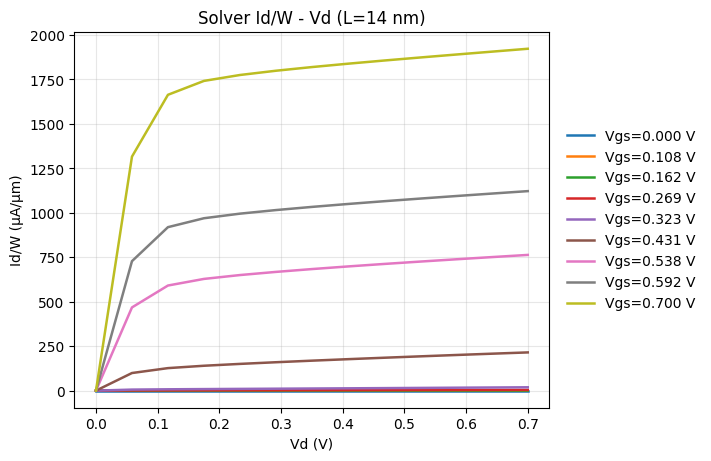

Plotted solver curves: 9 Vgs lines: [0.     0.1077 0.1615 0.2692 0.3231 0.4308 0.5385 0.5923 0.7   ]


In [18]:
import numpy as np
import matplotlib.pyplot as plt

Vgs = np.asarray(results['Vgs'])
Vds = np.asarray(results['Vds'])
J = np.asarray(results['J'])  # shape: (Nvg, Nvd)

# 1 A/m == 1 μA/μm numerically, so we can relabel directly.
IdW_uA_per_um = J

# Select 9 representative gate-bias curves across the available Vgs range.
target_vgs = np.linspace(Vgs.min(), Vgs.max(), 9)
sel_idx = [int(np.argmin(np.abs(Vgs - v))) for v in target_vgs]
sel_idx = list(dict.fromkeys(sel_idx))

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

for i in sel_idx:
    ax.plot(Vds, IdW_uA_per_um[i, :], lw=1.8, label=f"Vgs={Vgs[i]:.3f} V")

ax.set_title("Solver Id/W - Vd (L=14 nm)")
ax.set_xlabel("Vd (V)")
ax.set_ylabel("Id/W (μA/μm)")
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.show()

print("Plotted solver curves:", len(sel_idx), "Vgs lines:", np.round(Vgs[sel_idx], 4))

## log(Id/W) - Vd
MOSFET output characteristic on a logarithmic current scale versus drain voltage at fixed gate biases.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Vgs = np.asarray(results['Vgs'])
Vds = np.asarray(results['Vds'])
J = np.asarray(results['J'])  # shape: (Nvg, Nvd)

# 1 A/m == 1 μA/μm numerically.
IdW_uA_per_um = J

# Semilog plots require strictly positive values.
# Use absolute current magnitude with a tiny floor for numerical stability.
floor_uA_per_um = 1e-12
IdW_log = np.maximum(np.abs(IdW_uA_per_um), floor_uA_per_um)

# Select 9 representative gate-bias curves.
target_vgs = np.linspace(Vgs.min(), Vgs.max(), 9)
sel_idx = [int(np.argmin(np.abs(Vgs - v))) for v in target_vgs]
sel_idx = list(dict.fromkeys(sel_idx))

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

for i in sel_idx:
    ax.semilogy(Vds, IdW_log[i, :], lw=1.8, label=f"Vgs={Vgs[i]:.3f} V")

ax.set_title("Solver log(Id/W) - Vd (L=14 nm)")
ax.set_xlabel("Vd (V)")
ax.set_ylabel("|Id/W| (μA/μm)")
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.show()

print("Plotted log-scale solver curves:", len(sel_idx), "Vgs lines:", np.round(Vgs[sel_idx], 4))
print("Log floor used (μA/μm):", floor_uA_per_um)
